## Figure 3 stuff

### Harringtonine

In [88]:
import croparray as ca
from pathlib import Path
%gui qt
# ============================
# USER-DEFINED PARAMETERS
# ============================
from pathlib import Path
INPUT_FILE = Path(r'Z:\galindo\1_Imaging_Data\2_Comparing_Translation_methods\12xST_KDM5B\HT_data\Combined\Rep3_20250822_RNA_TIRF\Cell02.nc') # Combined stack array

In [89]:
# Need to open this way to get proper doc strings:
import croparray as ca
from croparray.trackarray.object import TrackArray
my_ca: TrackArray = ca.io.open_croparray(INPUT_FILE, as_object=True)

[CropArray] No sidecars found.


In [90]:
my_ca['time after harringtonine (min)'] = my_ca['t']-4
my_ca['intensity (a.u.)'] = my_ca['signal']/500

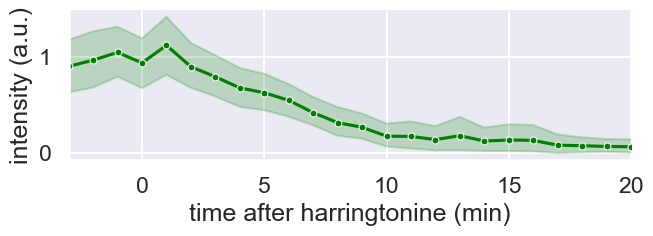

In [91]:
sns.set_context("talk")
g = my_ca.plot.relplot(x="time after harringtonine (min)", y="intensity (a.u.)", kind="line", facet_kws={"sharey": True},height=2.7, aspect=2.5, color='green', marker="o", markersize=5)
g.set(xlim=(-3, 20))
#g.set(ylim=(-0.02, 1.2))
# g.fig.savefig(INPUT_FILE.with_suffix(".svg"), format="svg", bbox_inches="tight")

C:\Users\tstasevi\AppData\Local\Temp\ipykernel_12936\1888155525.py:3: DeprecationWarning: self.axes is deprecated since 2022.11 in order to align with matplotlibs plt.subplots, use self.axs instead.
  for ax in g.axes.flat:


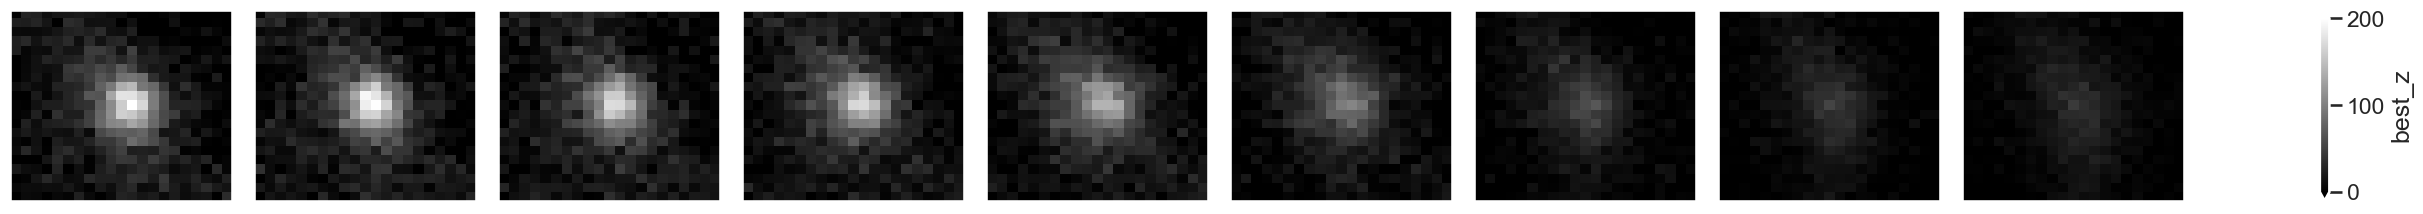

In [ ]:
g=my_ca['best_z'].isel(ch=0).mean(dim=['n','fov']).rolling(t=5, center=True, min_periods=1).mean().isel(t=slice(3, 20, 2)).plot.imshow(col="t", cmap='gray',robust=True, vmin=0,vmax=200,xticks=[],yticks=[],)

for ax in g.axes.flat:
    ax.set_title("")
    ax.set_xlabel("")
    ax.set_ylabel("")

### FCS

In [2]:
import croparray as ca
from pathlib import Path
%gui qt
# ============================
# USER-DEFINED PARAMETERS
# ============================
from pathlib import Path
FCS_TRACE = Path(r'Z:\klink\ProtocolPaper2026\FCS_trace_data.csv') # Combined stack array
FCS_AC = Path(r'Z:\klink\ProtocolPaper2026\FCS_autocorr_data.csv') # Combined stack array

In [17]:
fcs_raw=pd.read_csv(FCS_TRACE)
fcs_ac = pd.read_csv(FCS_AC)

In [36]:
fcs_raw['time (sec)'] = fcs_raw['time']*7
fcs_raw["Cell01_1z_tracks_filtered_11_rn"] = fcs_raw["Cell01_1z_tracks_filtered_11"]/100 

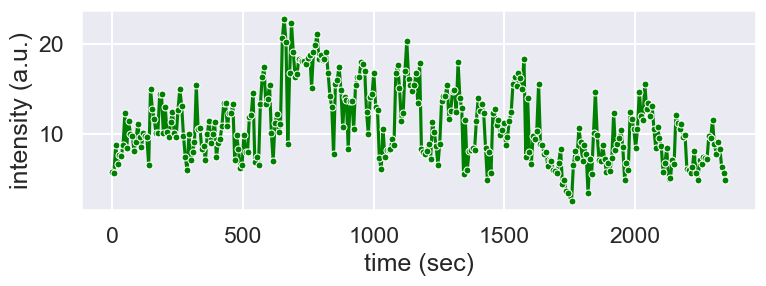

In [38]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style("darkgrid")
sns.set_context("talk")

plt.figure(figsize=(8,3.2))  # change size here

sns.lineplot(
    data=fcs_raw,
    x="time (sec)",
    y="Cell01_1z_tracks_filtered_11_rn",
    color='green',
    marker='o',
    markersize=5,
)

plt.ylabel(r"intensity (a.u.)")

#plt.xlabel(r"$\tau$ (s)")
#plt.ylabel(r"$G(\tau)$")

plt.tight_layout()
plt.show()

In [66]:
fcs_ac['Autocorrelation G(τ)']=fcs_ac['G(τ) norm']
fcs_ac['τ (min)'] = fcs_ac['τ']/60

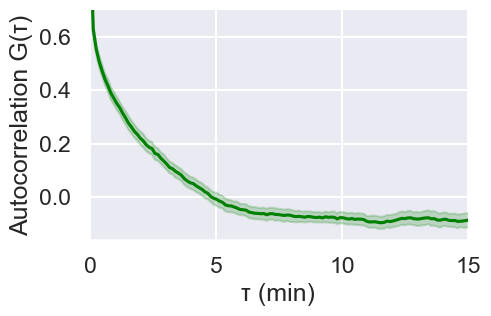

In [87]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.set_style("darkgrid")
g = sns.relplot(
    data=fcs_ac,
    x="τ (min)",
    y="Autocorrelation G(τ)",
    color='green',
    height=3.5,
    aspect=1.5,
    kind='line',
)
g.set(xlim=(-6/60, 900/60))
g.set(ylim=(-0.16, 0.7))
plt.tight_layout()
plt.show()